Device: cuda

Training SGD with Momentum...
SGD Epoch 1 Loss: 1.7022 Accuracy: 40.04 %
SGD Epoch 2 Loss: 1.4841 Accuracy: 48.12 %
SGD Epoch 3 Loss: 1.3846 Accuracy: 51.69 %
SGD Epoch 4 Loss: 1.3171 Accuracy: 54.18 %
SGD Epoch 5 Loss: 1.2625 Accuracy: 56.04 %
SGD Epoch 6 Loss: 1.2033 Accuracy: 58.34 %
SGD Epoch 7 Loss: 1.1627 Accuracy: 59.6 %
SGD Epoch 8 Loss: 1.1212 Accuracy: 61.18 %
SGD Epoch 9 Loss: 1.0799 Accuracy: 62.66 %
SGD Epoch 10 Loss: 1.0464 Accuracy: 63.75 %

Training Adam...
Adam Epoch 1 Loss: 1.6312 Accuracy: 42.73 %
Adam Epoch 2 Loss: 1.4357 Accuracy: 49.86 %
Adam Epoch 3 Loss: 1.343 Accuracy: 53.32 %
Adam Epoch 4 Loss: 1.2748 Accuracy: 55.67 %
Adam Epoch 5 Loss: 1.2155 Accuracy: 57.68 %
Adam Epoch 6 Loss: 1.1669 Accuracy: 59.64 %
Adam Epoch 7 Loss: 1.115 Accuracy: 61.34 %
Adam Epoch 8 Loss: 1.0672 Accuracy: 63.13 %
Adam Epoch 9 Loss: 1.0257 Accuracy: 64.3 %
Adam Epoch 10 Loss: 0.9839 Accuracy: 65.98 %


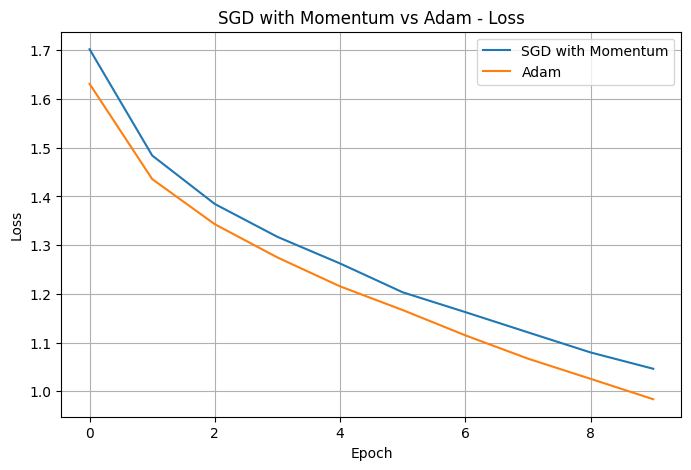

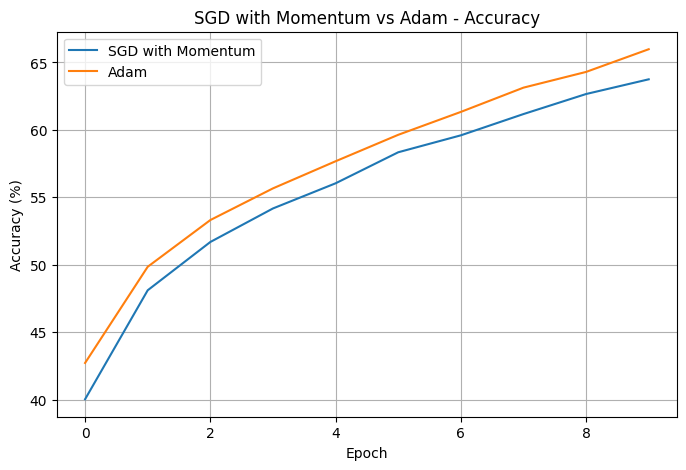

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

trainset = torchvision.datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

trainloader = torch.utils.data.DataLoader(
    trainset,
    batch_size=128,
    shuffle=True
)

class MLP(nn.Module):
    def __init__(self):
        super(MLP, self).__init__()

        self.network = nn.Sequential(
            nn.Flatten(),
            nn.Linear(3 * 32 * 32, 256),
            nn.ReLU(),
            nn.Linear(256, 10)
        )

    def forward(self, x):
        return self.network(x)

def train_model(optimizer_name):

    model = MLP().to(device)

    criterion = nn.CrossEntropyLoss()

    if optimizer_name == "SGD":
        optimizer = optim.SGD(
            model.parameters(),
            lr=0.01,
            momentum=0.9
        )
    else:
        optimizer = optim.Adam(
            model.parameters(),
            lr=0.001
        )

    losses = []
    accuracies = []

    for epoch in range(10):

        model.train()

        running_loss = 0
        correct = 0
        total = 0

        for images, labels in trainloader:

            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)

            loss = criterion(outputs, labels)

            loss.backward()

            optimizer.step()

            running_loss += loss.item()

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)

            correct += (predicted == labels).sum().item()

        epoch_loss = running_loss / len(trainloader)

        epoch_accuracy = 100 * correct / total

        losses.append(epoch_loss)

        accuracies.append(epoch_accuracy)

        print(
            optimizer_name,
            "Epoch",
            epoch + 1,
            "Loss:",
            round(epoch_loss, 4),
            "Accuracy:",
            round(epoch_accuracy, 2),
            "%"
        )

    return losses, accuracies

print("\nTraining SGD with Momentum...")
sgd_loss, sgd_acc = train_model("SGD")

print("\nTraining Adam...")
adam_loss, adam_acc = train_model("Adam")

plt.figure(figsize=(8, 5))

plt.plot(
    sgd_loss,
    label="SGD with Momentum"
)

plt.plot(
    adam_loss,
    label="Adam"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("SGD with Momentum vs Adam - Loss")

plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(8, 5))

plt.plot(
    sgd_acc,
    label="SGD with Momentum"
)

plt.plot(
    adam_acc,
    label="Adam"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("SGD with Momentum vs Adam - Accuracy")

plt.legend()
plt.grid()
plt.show()